In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

from src.data.load_data import load_cmapss_data, add_rul_column

# Load data
train_df, test_df, rul_df = load_cmapss_data('FD001', data_dir='../data/raw')
train_df = add_rul_column(train_df)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

✓ Loaded FD001
  Training data: (20631, 26)
  Test data: (13096, 26)
  RUL labels: (100, 1)


Engine cycle plot


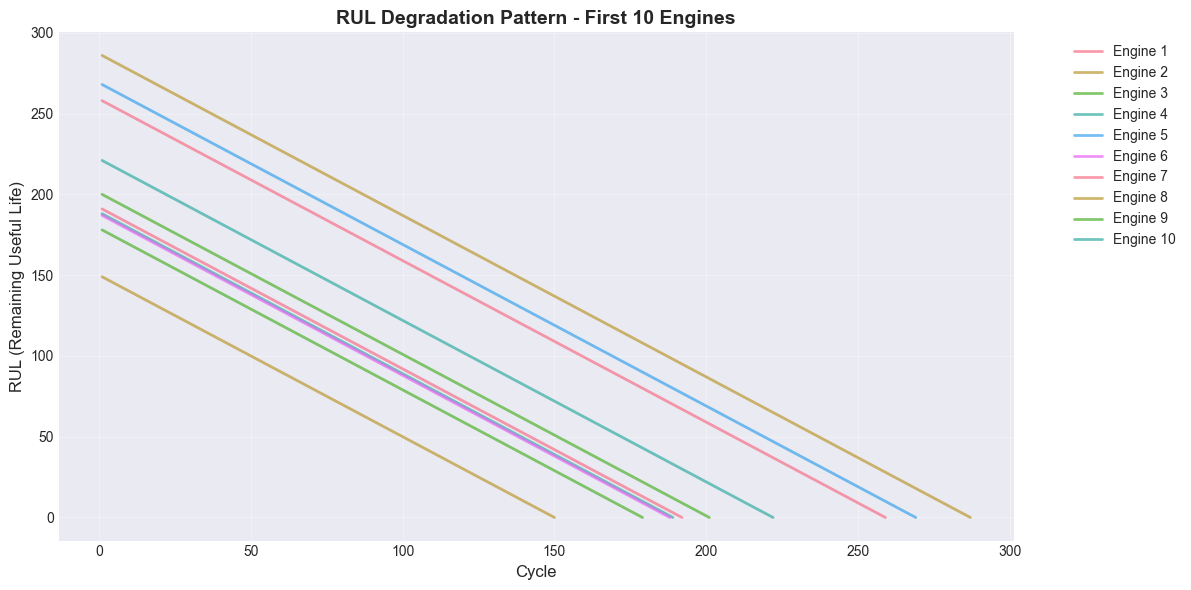

In [2]:
# Plot RUL for first 10 engines
fig, ax = plt.subplots(figsize=(12, 6))

for engine_id in range(1, 11):
    engine_data = train_df[train_df['engine_id'] == engine_id]
    ax.plot(engine_data['cycle'], engine_data['RUL'], 
            alpha=0.7, linewidth=2, label=f'Engine {engine_id}')

ax.set_xlabel('Cycle', fontsize=12)
ax.set_ylabel('RUL (Remaining Useful Life)', fontsize=12)
ax.set_title('RUL Degradation Pattern - First 10 Engines', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/rul_progression_10_engines.png', dpi=300, bbox_inches='tight')
plt.show()

Engine lifetime Distribution

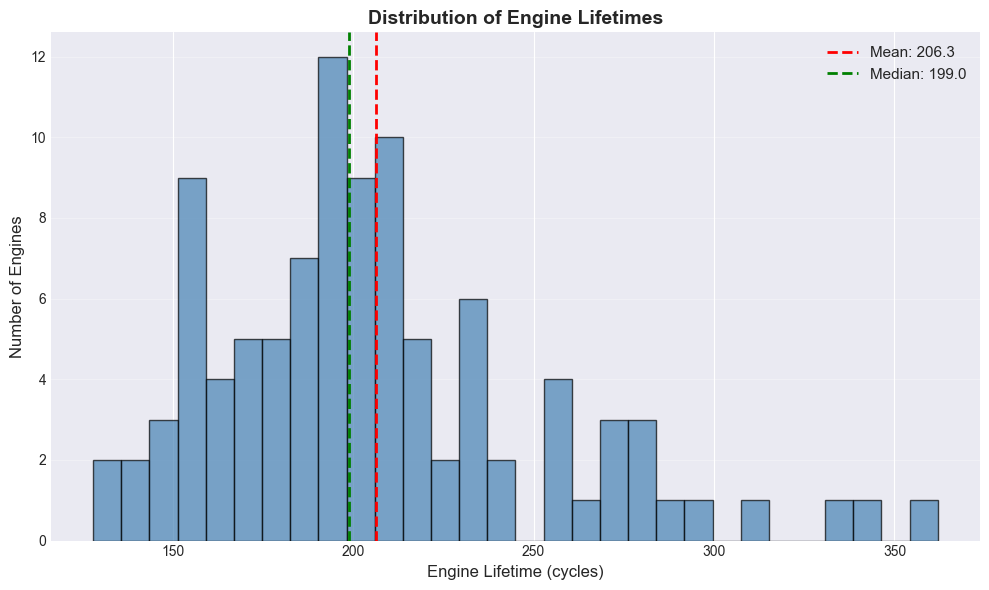

Lifetime Statistics:
  Min: 128 cycles
  Max: 362 cycles
  Mean: 206.3 cycles
  Median: 199.0 cycles
  Std: 46.3 cycles


In [3]:
# Histogram of engine lifetimes
engine_lifetimes = train_df.groupby('engine_id')['cycle'].max()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(engine_lifetimes, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(engine_lifetimes.mean(), color='red', linestyle='--', 
           linewidth=2, label=f'Mean: {engine_lifetimes.mean():.1f}')
ax.axvline(engine_lifetimes.median(), color='green', linestyle='--', 
           linewidth=2, label=f'Median: {engine_lifetimes.median():.1f}')
ax.set_xlabel('Engine Lifetime (cycles)', fontsize=12)
ax.set_ylabel('Number of Engines', fontsize=12)
ax.set_title('Distribution of Engine Lifetimes', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../results/figures/engine_lifetime_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Lifetime Statistics:")
print(f"  Min: {engine_lifetimes.min()} cycles")
print(f"  Max: {engine_lifetimes.max()} cycles")
print(f"  Mean: {engine_lifetimes.mean():.1f} cycles")
print(f"  Median: {engine_lifetimes.median():.1f} cycles")
print(f"  Std: {engine_lifetimes.std():.1f} cycles")

Sensors Trend overtime

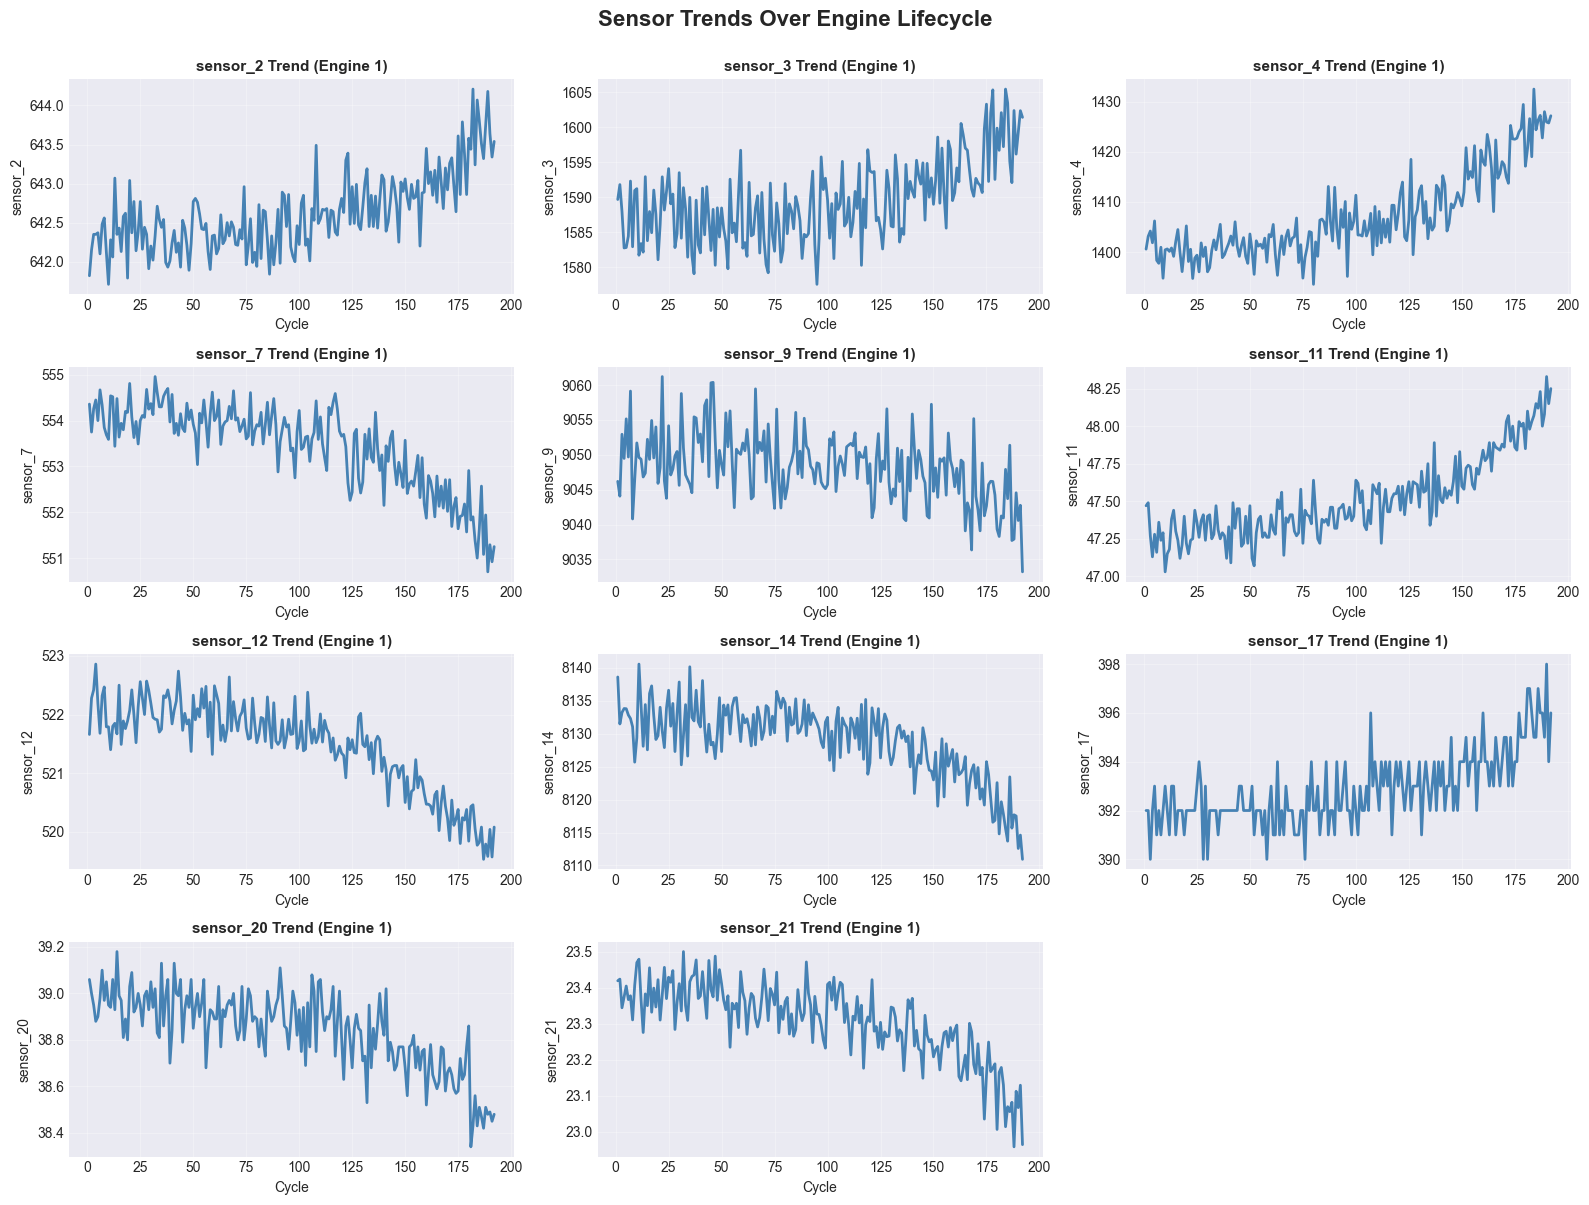

In [4]:
# Useful sensors (from your analysis)
useful_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9',
                  'sensor_11', 'sensor_12', 'sensor_14', 'sensor_17', 
                  'sensor_20', 'sensor_21']

# Plot sensor trends for Engine 1
engine_1 = train_df[train_df['engine_id'] == 1]

fig, axes = plt.subplots(4, 3, figsize=(16, 12))
axes = axes.flatten()

for i, sensor in enumerate(useful_sensors):
    axes[i].plot(engine_1['cycle'], engine_1[sensor], linewidth=2, color='steelblue')
    axes[i].set_xlabel('Cycle', fontsize=10)
    axes[i].set_ylabel(sensor, fontsize=10)
    axes[i].set_title(f'{sensor} Trend (Engine 1)', fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

# Hide extra subplot
axes[-1].axis('off')

plt.suptitle('Sensor Trends Over Engine Lifecycle', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../results/figures/sensor_trends_engine1.png', dpi=300, bbox_inches='tight')
plt.show()

Correlation heatmap

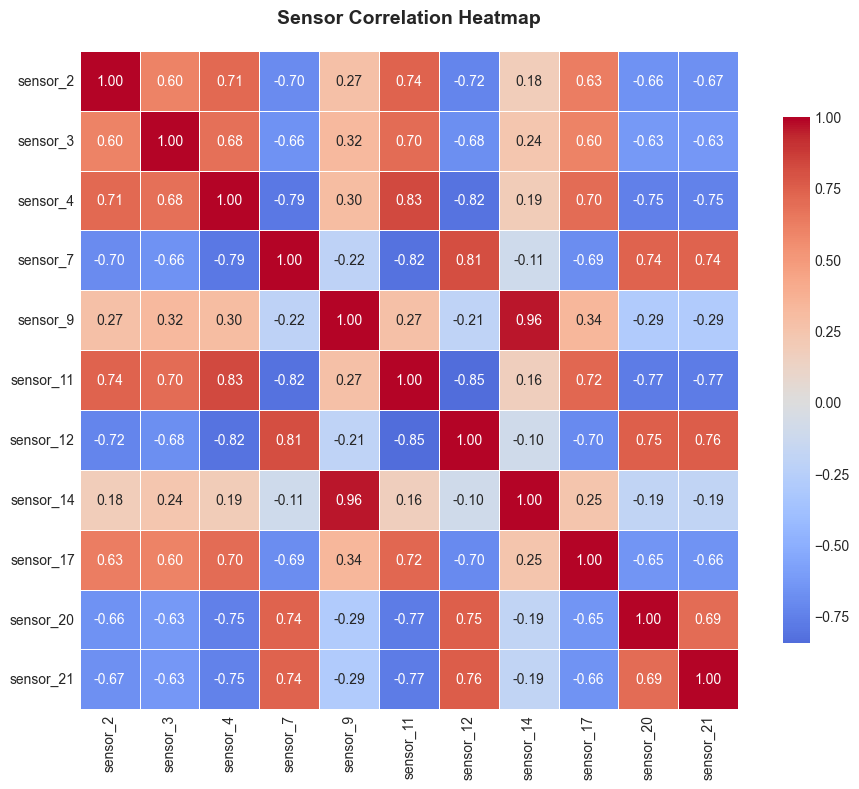

In [5]:
# Correlation matrix for useful sensors
sensor_data = train_df[useful_sensors]
correlation_matrix = sensor_data.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title('Sensor Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../results/figures/sensor_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

RUL distribution

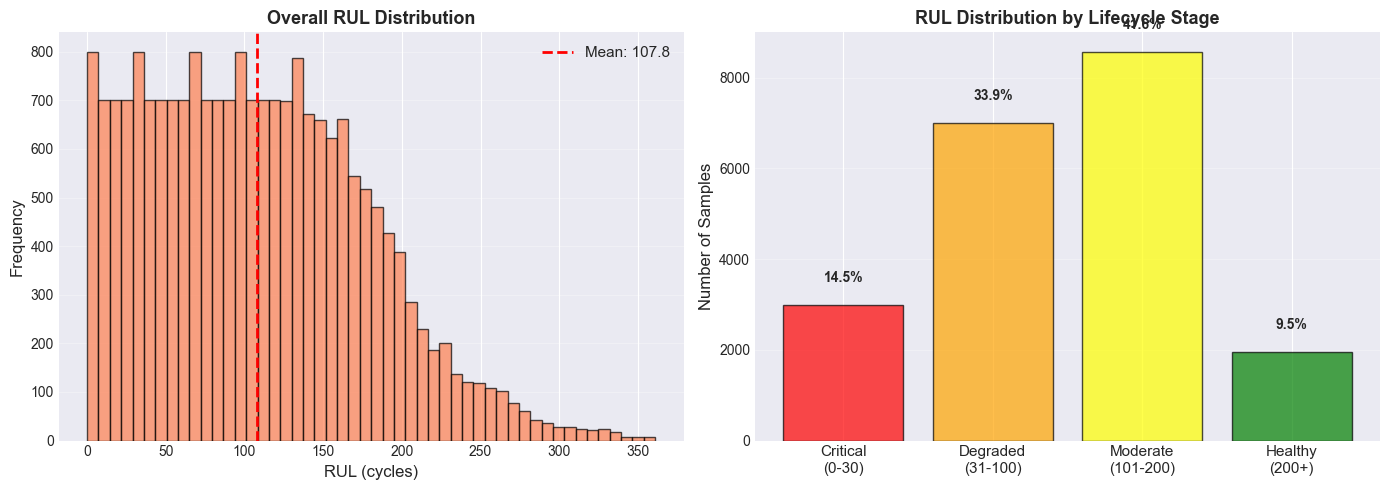


RUL Stage Distribution:
  Critical
(0-30): 3000 samples (14.5%)
  Degraded
(31-100): 7000 samples (33.9%)
  Moderate
(101-200): 8573 samples (41.6%)
  Healthy
(200+): 1958 samples (9.5%)


In [6]:
# RUL distribution with stages
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
axes[0].hist(train_df['RUL'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0].axvline(train_df['RUL'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {train_df["RUL"].mean():.1f}')
axes[0].set_xlabel('RUL (cycles)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Overall RUL Distribution', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')

# RUL by lifecycle stage
rul_stages = pd.cut(train_df['RUL'], bins=[0, 30, 100, 200, 400], 
                    labels=['Critical\n(0-30)', 'Degraded\n(31-100)', 
                           'Moderate\n(101-200)', 'Healthy\n(200+)'])
stage_counts = rul_stages.value_counts().sort_index()

axes[1].bar(range(len(stage_counts)), stage_counts.values, 
            color=['red', 'orange', 'yellow', 'green'], alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(len(stage_counts)))
axes[1].set_xticklabels(stage_counts.index, fontsize=11)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].set_title('RUL Distribution by Lifecycle Stage', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Add percentages
for i, v in enumerate(stage_counts.values):
    percentage = (v / len(train_df)) * 100
    axes[1].text(i, v + 500, f'{percentage:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/rul_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nRUL Stage Distribution:")
for stage, count in stage_counts.items():
    percentage = (count / len(train_df)) * 100
    print(f"  {stage}: {count} samples ({percentage:.1f}%)")

Healthy vs Degraded comparison

C:\Users\Samiya\AppData\Local\Temp\ipykernel_18772\1241857014.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([healthy[sensor], degraded[sensor]],
C:\Users\Samiya\AppData\Local\Temp\ipykernel_18772\1241857014.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([healthy[sensor], degraded[sensor]],
C:\Users\Samiya\AppData\Local\Temp\ipykernel_18772\1241857014.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([healthy[sensor], degraded[sensor]],
C:\Users\Samiya\AppData\Local\Temp\ipykernel_18772\1241857014.py:13: MatplotlibDeprecationWarning: The 'labels' parameter

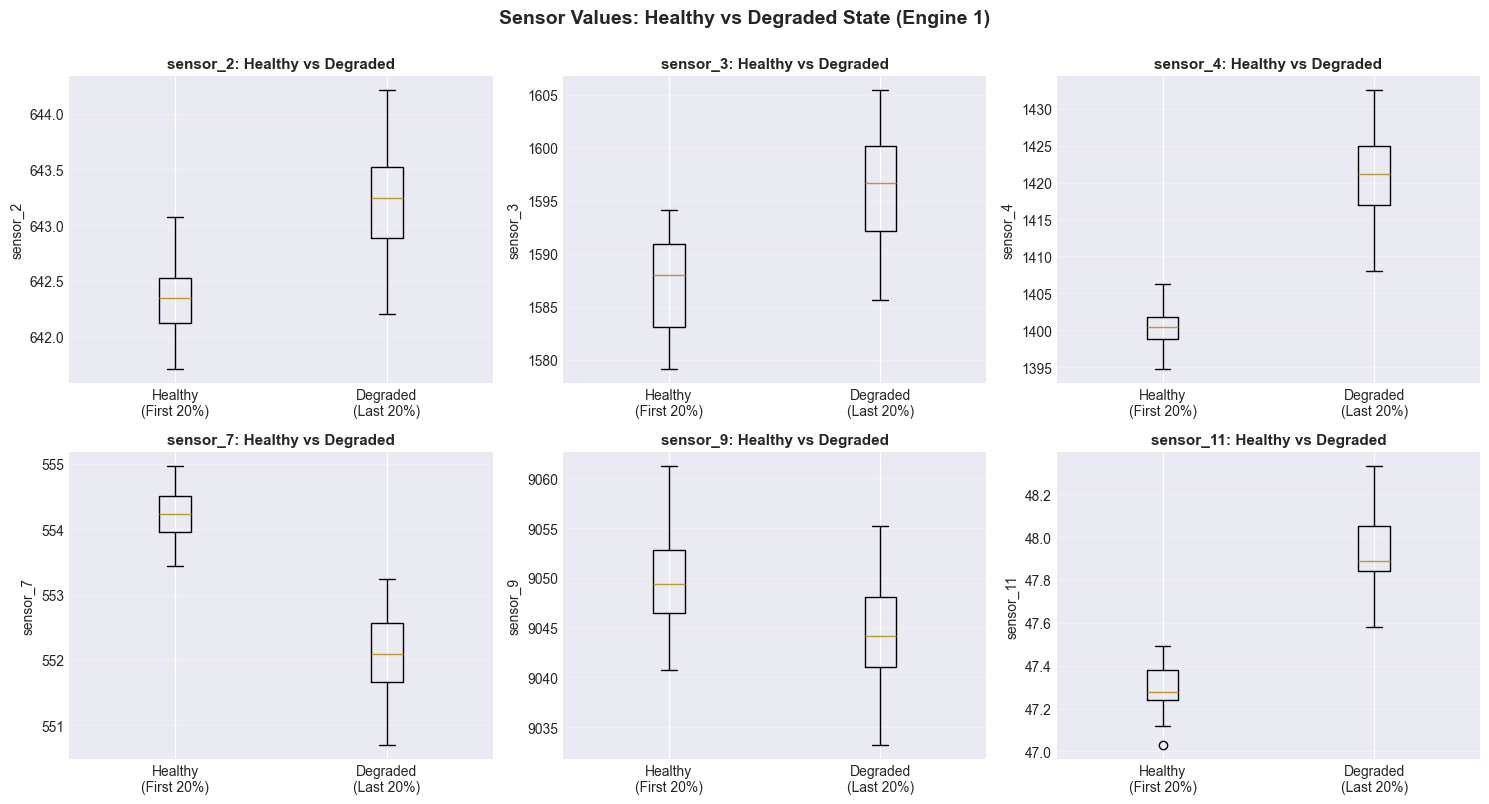

In [7]:
# Compare sensor values: healthy (first 20%) vs degraded (last 20%)
engine_1 = train_df[train_df['engine_id'] == 1]
healthy_cutoff = int(len(engine_1) * 0.2)
degraded_start = int(len(engine_1) * 0.8)

healthy = engine_1.iloc[:healthy_cutoff]
degraded = engine_1.iloc[degraded_start:]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, sensor in enumerate(useful_sensors[:6]):
    axes[i].boxplot([healthy[sensor], degraded[sensor]], 
                    labels=['Healthy\n(First 20%)', 'Degraded\n(Last 20%)'])
    axes[i].set_ylabel(sensor, fontsize=10)
    axes[i].set_title(f'{sensor}: Healthy vs Degraded', fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Sensor Values: Healthy vs Degraded State (Engine 1)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../results/figures/healthy_vs_degraded_sensors.png', dpi=300, bbox_inches='tight')
plt.show()

Operating condition verfication

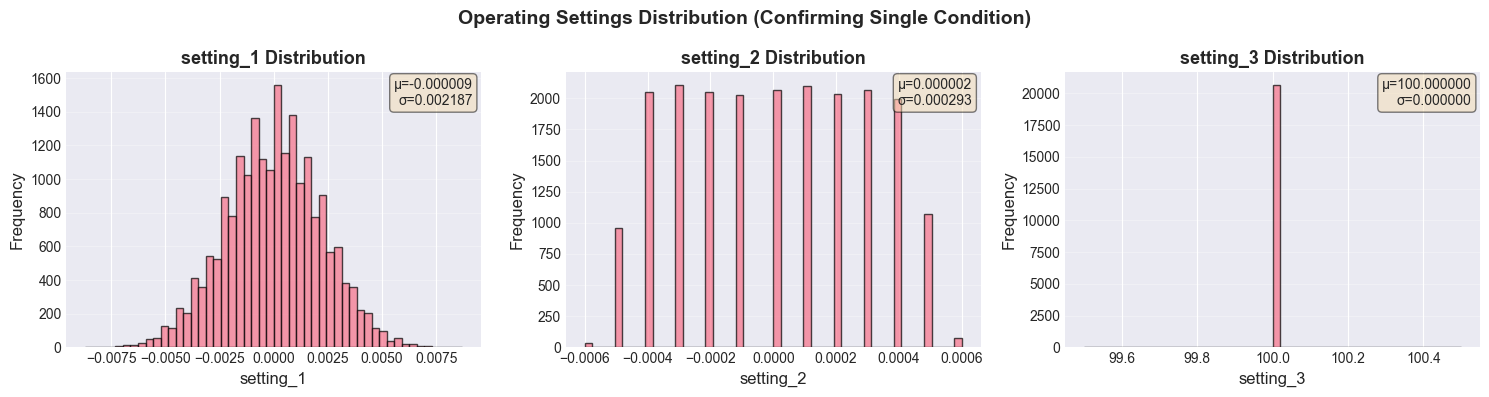

In [8]:
# Verify settings are constant
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

settings = ['setting_1', 'setting_2', 'setting_3']
for i, setting in enumerate(settings):
    axes[i].hist(train_df[setting], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(setting, fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)
    axes[i].set_title(f'{setting} Distribution', fontsize=13, fontweight='bold')
    axes[i].grid(True, alpha=0.3, axis='y')
    
    # Add statistics
    mean_val = train_df[setting].mean()
    std_val = train_df[setting].std()
    axes[i].text(0.98, 0.98, f'μ={mean_val:.6f}\nσ={std_val:.6f}', 
                transform=axes[i].transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Operating Settings Distribution (Confirming Single Condition)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/operating_settings_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
